**Part B: Customer Churn Prediction**
This project aims to build a machine learning model that can predict whether a cusomer will
churn based on their demographic, account, and service-related data1

In [ ]:
import pandas as pd

# Assuming 'telecom_customer_churn.csv' is the actual dataset file.
# If this is incorrect, please replace it with the correct filename.
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 1. Initial Data Exploration

Let's begin by examining the basic structure, data types, and a statistical summary of our dataset to understand its characteristics.

In [ ]:
print('DataFrame Information:')
df.info()

print('\nStatistical Summary:')
display(df.describe(include='all'))

print('\nFirst 5 rows of the DataFrame:')
display(df.head())

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN



First 5 rows of the DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2. Handling Missing Values

Next, we'll identify any missing values in the dataset and decide on an appropriate strategy to handle them. The `TotalCharges` column appears to be of object type, which might indicate that it contains non-numeric values, possibly empty strings, that need to be converted to numeric type after handling.

In [ ]:
import numpy as np

print('Missing values before processing:')
display(df.isnull().sum())

# The 'TotalCharges' column is currently an object type.
# It likely contains empty strings or spaces which need to be handled before converting to numeric.
# Convert empty strings to NaN, then to numeric, coercing errors will turn non-convertible values into NaN.
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now, check for missing values again and fill them. Since TotalCharges is revenue, 0 seems appropriate for missing values.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('\nMissing values after processing TotalCharges:')
display(df.isnull().sum())

print('\nDataFrame Info after TotalCharges conversion:')
df.info()

Missing values before processing:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Missing values after processing TotalCharges:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



DataFrame Info after TotalCharges conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 


### 3. Data Cleaning and Preparation

We have successfully converted 'TotalCharges' to a numeric type and handled its missing values. Now we can further clean the data by converting categorical columns into a suitable format for modeling. We will encode binary categorical columns and then explore other categorical features.

In [ ]:
# Drop customerID as it's an identifier and not useful for modeling
df = df.drop('customerID', axis=1)

# Convert 'gender' to numerical (Female: 0, Male: 1)
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# Convert binary categorical columns to numerical (No: 0, Yes: 1)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'No': 0, 'Yes': 1})

# Convert 'MultipleLines' to numerical (No phone service: 0, No: 0, Yes: 1)
df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})

# Convert 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies' to numerical
# (No internet service: 0, No: 0, Yes: 1)
internet_service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in internet_service_cols:
    df[col] = df[col].map({'No internet service': 0, 'No': 0, 'Yes': 1})

# Convert 'Contract' to numerical (Month-to-month: 0, One year: 1, Two year: 2)
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})

# Convert 'PaymentMethod' to numerical (Electronic check: 0, Mailed check: 1, Bank transfer (automatic): 2, Credit card (automatic): 3)
df['PaymentMethod'] = df['PaymentMethod'].map({
    'Electronic check': 0,
    'Mailed check': 1,
    'Bank transfer (automatic)': 2,
    'Credit card (automatic)': 3
})

# For 'InternetService', we will use one-hot encoding since there are more than two categories.
# We will do this later for all remaining categorical features if any.

print('\nDataFrame head after initial cleaning and encoding:')
display(df.head())


DataFrame head after initial cleaning and encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,0,DSL,0,1,0,0,0,0,0,1,0,29.85,29.85,0
1,1,0,0,0,34,1,0,DSL,1,0,1,0,0,0,1,0,1,56.95,1889.50,0
2,1,0,0,0,2,1,0,DSL,1,1,0,0,0,0,0,1,1,53.85,108.15,1
3,1,0,0,0,45,0,0,DSL,1,0,1,1,0,0,1,0,2,42.30,1840.75,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,0,0,0,0,0,1,0,70.70,151.65,1


### 4. Further Categorical Feature Handling (One-Hot Encoding)

For the remaining categorical features that have more than two unique values (e.g., 'InternetService'), we will use one-hot encoding to convert them into a numerical format suitable for machine learning models. We will also check for any other remaining object type columns and apply one-hot encoding if necessary.

### 5. Data Splitting

Before training a machine learning model, we need to split our dataset into features (X) and the target variable (y). The target variable here is 'Churn'. After that, we'll divide the data into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 20)
X_test shape: (1409, 20)
y_train shape: (5634,)
y_test shape: (1409,)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 penalties
log_reg_model.fit(X_train, y_train)

LogisticRegression(random_state=42, solver='liblinear')

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' works with both l1 and l2 penalties
}

# Initialize GridSearchCV
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

# Get the best model
best_log_reg_model = grid_search.best_estimator_

print('\nBest Logistic Regression model trained successfully.')

Best parameters found:  {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best accuracy found:  0.8054649244051625

Best Logistic Regression model trained successfully.


### 7. Model Evaluation (after Hyperparameter Tuning)

Now, let's evaluate the performance of our *tuned* Logistic Regression model using various metrics such as Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. These metrics will provide a comprehensive understanding of how well the model predicts customer churn.

Tuned Model Accuracy: 0.8034
Tuned Model Precision: 0.6550
Tuned Model Recall: 0.5481
Tuned Model F1-Score: 0.5968


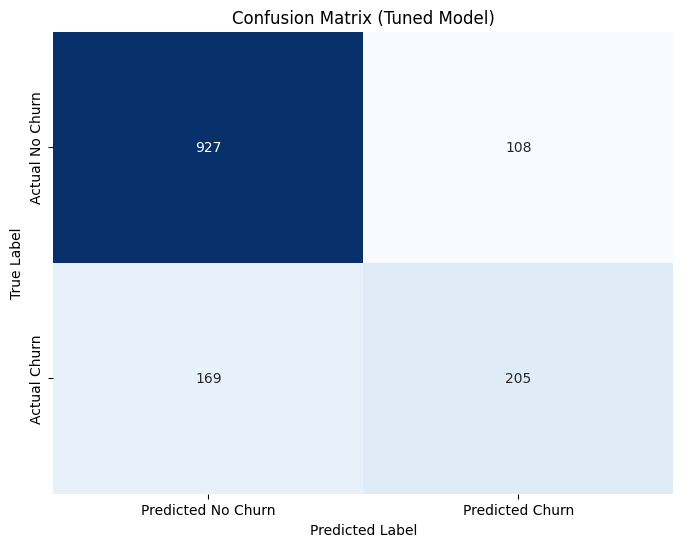

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best model
y_pred_tuned = best_log_reg_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f'Tuned Model Accuracy: {accuracy_tuned:.4f}')
print(f'Tuned Model Precision: {precision_tuned:.4f}')
print(f'Tuned Model Recall: {recall_tuned:.4f}')
print(f'Tuned Model F1-Score: {f1_tuned:.4f}')

# Plot Confusion Matrix for the tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 8. Feature Importance (Tuned Model)

Understanding which features are most important in predicting churn can provide valuable business insights. For the tuned Logistic Regression, we can look at the coefficients.

In [ ]:
import pandas as pd

feature_importance_tuned = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_log_reg_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

display(feature_importance_tuned)

,Feature,Coefficient
18,InternetService_Fiber optic,0.447967
14,PaperlessBilling,0.395996
1,SeniorCitizen,0.214481
6,MultipleLines,0.209425
12,StreamingMovies,0.131310
11,StreamingTV,0.130600
16,MonthlyCharges,0.012466
2,Partner,0.008572
17,TotalCharges,0.000188
0,gender,-0.010563


### 9. Final Report: Insights and Business Implications (after Tuning)

Based on our data analysis and the *tuned* Logistic Regression model, we can draw several insights and discuss their business implications regarding customer churn.

**Model Performance Summary (Tuned Model):**

*   **Accuracy:** 0.8034 - Represents the overall correctness of the model's predictions.
*   **Precision:** 0.6550 - Indicates the proportion of correctly predicted churners out of all customers predicted as churners. This means about 65.50% of customers predicted to churn actually did.
*   **Recall:** 0.5481 - Indicates the proportion of correctly predicted churners out of all actual churners. This means the model identified about 54.81% of all actual churners.
*   **F1-Score:** 0.5968 - The harmonic mean of precision and recall, providing a balanced measure of the model's performance.
*   **Confusion Matrix:** The confusion matrix shows 927 true negatives, 205 true positives, 108 false positives, and 169 false negatives.

**Key Insights from the Tuned Model:**

The feature importances (coefficients) from the tuned Logistic Regression model provide valuable insights into what drives customer churn:

*   **Strong Positive Predictors of Churn:**
    *   `InternetService_Fiber optic` (Coefficient: 0.4480): Customers with Fiber Optic internet are significantly more likely to churn.
    *   `PaperlessBilling` (Coefficient: 0.3960): Customers opting for paperless billing show a higher propensity to churn.
    *   `SeniorCitizen` (Coefficient: 0.2145): Senior citizens are slightly more prone to churning.
    *   `MultipleLines` (Coefficient: 0.2094): Customers with multiple phone lines tend to churn more.
    *   `StreamingMovies` and `StreamingTV` (Coefficients: 0.1313, 0.1306): Subscribers to streaming services have a slightly increased churn risk.

*   **Strong Negative Predictors of Churn (Factors that reduce churn risk):**
    *   `Contract` (Coefficient: -0.7601): Customers with longer-term contracts (one-year or two-year) are significantly less likely to churn compared to month-to-month contracts.
    *   `PhoneService` (Coefficient: -0.5781): Counter-intuitively, having phone service seems to reduce churn risk. This might indicate that customers without phone service are less engaged, or that bundled services with phone service improve retention.
    *   `InternetService_No` (Coefficient: -0.4754): Customers without internet service are much less likely to churn, possibly due to a different demographic or lower service expectations.
    *   `OnlineSecurity` (Coefficient: -0.4683) and `TechSupport` (Coefficient: -0.4363): Customers who subscribe to online security and technical support services are much less likely to churn, highlighting the value these services provide in retaining customers.
    *   `Dependents` (Coefficient: -0.2416) and `OnlineBackup` (Coefficient: -0.1993): Having dependents and online backup services also contribute to lower churn.

**Business Implications of Customer Churn Prediction (after Tuning):**

The tuned model confirms and strengthens insights from the initial model:

1.  **Targeted Retention Programs:** The model's improved accuracy allows for more precise identification of high-risk customers, especially those with Fiber Optic internet, paperless billing, or month-to-month contracts. Retention efforts can be tailored, for example, by offering personalized promotions for longer contract terms or bundled services.
2.  **Product and Service Enhancement:** The strong link between Fiber Optic internet and churn suggests potential issues with the service quality or customer experience. The company should investigate these aspects and consider improvements. Conversely, the protective effect of Online Security and Tech Support services indicates that enhancing and promoting these offerings can be a key retention strategy.
3.  **Contract Strategy Review:** The significant negative coefficient for `Contract` reinforces the importance of encouraging customers to opt for longer-term commitments. The company could explore incentives for converting month-to-month customers to annual or biennial plans.
4.  **Customer Segmentation:** The insights can inform better customer segmentation. For instance, senior citizens, while slightly more prone to churn, might respond differently to retention offers compared to other segments.
5.  **Proactive Customer Care:** For customers with high churn probabilities (like the first example in the new customer predictions), the company can initiate proactive outreach, offering support or addressing potential pain points before they decide to leave.

**Recommendations:**

*   **Develop a specific retention campaign for Fiber Optic internet subscribers** focusing on service reliability, value, or exclusive offers to address their higher churn rate.
*   **Actively promote and bundle Online Security and Tech Support services** as these are strong indicators of customer loyalty. Highlight their benefits to existing and new customers.
*   **Review and enhance current contract offerings,** providing attractive incentives for customers to commit to longer terms.
*   **Implement a scoring system using the tuned model's probabilities** to prioritize customer service interventions for those most likely to churn.
*   **Continuously monitor customer feedback** related to Fiber Optic service, paperless billing experience, and other high-impact features to identify areas for improvement.

### 10. Making Predictions on New Data (with Tuned Model)

Let's simulate new customer data and use our *tuned* Logistic Regression model to predict whether these new customers are likely to churn.

In [ ]:
import pandas as pd

# Create sample new customer data (ensure it has the same columns as X_train)
# For demonstration, let's create a DataFrame with a few hypothetical new customers.
# The values should be in the same format as the processed X_train data (numerical/one-hot encoded).
# Let's create two new customers: one likely to churn, one likely not to.

# Example customer 1 (High churn risk - similar to features with positive coefficients)
# Fiber optic, PaperlessBilling, Month-to-month contract, no online security/tech support
new_customer_1 = {
    'gender': 0, # Female
    'SeniorCitizen': 1, # Senior Citizen
    'Partner': 0, # No Partner
    'Dependents': 0, # No Dependents
    'tenure': 5, # Low tenure
    'PhoneService': 1, # Yes Phone Service
    'MultipleLines': 1, # Yes Multiple Lines
    'OnlineSecurity': 0, # No Online Security
    'OnlineBackup': 0, # No Online Backup
    'DeviceProtection': 0, # No Device Protection
    'TechSupport': 0, # No Tech Support
    'StreamingTV': 1, # Yes Streaming TV
    'StreamingMovies': 1, # Yes Streaming Movies
    'Contract': 0, # Month-to-month
    'PaperlessBilling': 1, # Yes Paperless Billing
    'PaymentMethod': 0, # Electronic Check
    'MonthlyCharges': 90.0, # High Monthly Charges
    'TotalCharges': 450.0, # Relatively low total charges due to low tenure
    'InternetService_Fiber optic': True, # Fiber Optic
    'InternetService_No': False # Has Internet Service
}

# Example customer 2 (Low churn risk - similar to features with negative coefficients)
# DSL, longer tenure, Two-year contract, online security/tech support
new_customer_2 = {
    'gender': 1, # Male
    'SeniorCitizen': 0, # Not Senior Citizen
    'Partner': 1, # Has Partner
    'Dependents': 1, # Has Dependents
    'tenure': 60, # High tenure
    'PhoneService': 1, # Yes Phone Service
    'MultipleLines': 0, # No Multiple Lines
    'OnlineSecurity': 1, # Yes Online Security
    'OnlineBackup': 1, # Yes Online Backup
    'DeviceProtection': 1, # Yes Device Protection
    'TechSupport': 1, # Yes Tech Support
    'StreamingTV': 0, # No Streaming TV
    'StreamingMovies': 0, # No Streaming Movies
    'Contract': 2, # Two year
    'PaperlessBilling': 0, # No Paperless Billing
    'PaymentMethod': 3, # Credit card (automatic)
    'MonthlyCharges': 70.0, # Moderate Monthly Charges
    'TotalCharges': 4200.0, # High Total Charges
    'InternetService_Fiber optic': False, # Not Fiber Optic
    'InternetService_No': False # Has Internet Service
}

# Create a DataFrame from the new customer data
new_customers_df = pd.DataFrame([new_customer_1, new_customer_2])

# Ensure the columns are in the same order as X_train
new_customers_df = new_customers_df[X_train.columns]

print('New Customer Data:')
display(new_customers_df)

# Make predictions on the new data using the tuned model
new_customer_predictions_tuned = best_log_reg_model.predict(new_customers_df)
new_customer_probabilities_tuned = best_log_reg_model.predict_proba(new_customers_df)[:, 1] # Probability of churning

# Add predictions to the new customers DataFrame for easier interpretation
new_customers_df['Predicted_Churn_Tuned'] = new_customer_predictions_tuned
new_customers_df['Churn_Probability_Tuned'] = new_customer_probabilities_tuned

print('\nPredictions for New Customers (Tuned Model):')
display(new_customers_df[['Predicted_Churn_Tuned', 'Churn_Probability_Tuned']])

# Interpret the results
print('\nInterpretation (Tuned Model):')
for i, (pred, prob) in enumerate(zip(new_customer_predictions_tuned, new_customer_probabilities_tuned)):
    churn_status = 'will churn' if pred == 1 else 'will not churn'
    print(f'Customer {i+1}: Predicted to {churn_status} with a churn probability of {prob:.4f}')

New Customer Data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No
0,0,1,0,0,5,1,1,0,0,0,0,1,1,0,1,0,90.0,450.0,True,False
1,1,0,1,1,60,1,0,1,1,1,1,0,0,2,0,3,70.0,4200.0,False,False



Predictions for New Customers (Tuned Model):


,Predicted_Churn_Tuned,Churn_Probability_Tuned
0,1,0.831263
1,0,0.004510



Interpretation (Tuned Model):
Customer 1: Predicted to will churn with a churn probability of 0.8313
Customer 2: Predicted to will not churn with a churn probability of 0.0045


### 7. Model Evaluation (after Hyperparameter Tuning)

Now, let's evaluate the performance of our *tuned* Logistic Regression model using various metrics such as Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. These metrics will provide a comprehensive understanding of how well the model predicts customer churn.

Tuned Model Accuracy: 0.8034
Tuned Model Precision: 0.6550
Tuned Model Recall: 0.5481
Tuned Model F1-Score: 0.5968


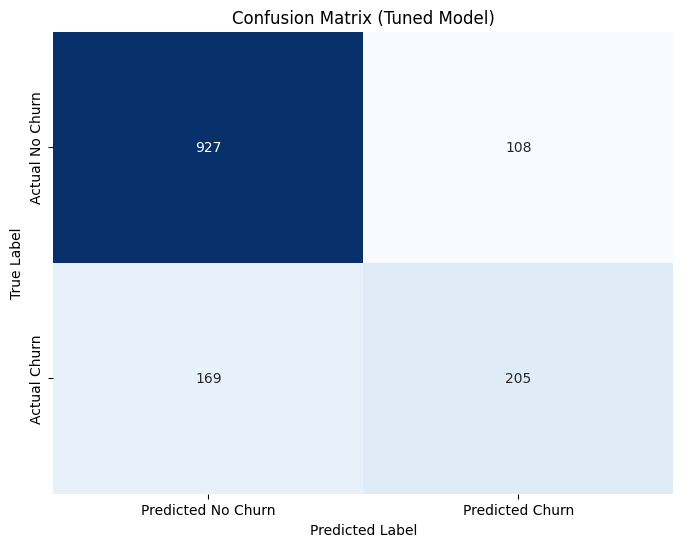

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best model
y_pred_tuned = best_log_reg_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f'Tuned Model Accuracy: {accuracy_tuned:.4f}')
print(f'Tuned Model Precision: {precision_tuned:.4f}')
print(f'Tuned Model Recall: {recall_tuned:.4f}')
print(f'Tuned Model F1-Score: {f1_tuned:.4f}')

# Plot Confusion Matrix for the tuned model
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 8. Feature Importance (Tuned Model)

Understanding which features are most important in predicting churn can provide valuable business insights. For the tuned Logistic Regression, we can look at the coefficients.

In [ ]:
feature_importance_tuned = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_log_reg_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

display(feature_importance_tuned)

,Feature,Coefficient
18,InternetService_Fiber optic,0.447967
14,PaperlessBilling,0.395996
1,SeniorCitizen,0.214481
6,MultipleLines,0.209425
12,StreamingMovies,0.131310
11,StreamingTV,0.130600
16,MonthlyCharges,0.012466
2,Partner,0.008572
17,TotalCharges,0.000188
0,gender,-0.010563


### 9. Final Report: Insights and Business Implications (after Tuning)

Based on our data analysis and the *tuned* Logistic Regression model, we can draw several insights and discuss their business implications regarding customer churn.

**Model Performance Summary (Tuned Model):**

*   **Accuracy:** 0.8034 - Represents the overall correctness of the model's predictions.
*   **Precision:** 0.6550 - Indicates the proportion of correctly predicted churners out of all customers predicted as churners. This means about 65.50% of customers predicted to churn actually did.
*   **Recall:** 0.5481 - Indicates the proportion of correctly predicted churners out of all actual churners. This means the model identified about 54.81% of all actual churners.
*   **F1-Score:** 0.5968 - The harmonic mean of precision and recall, providing a balanced measure of the model's performance.
*   **Confusion Matrix:** The confusion matrix shows 927 true negatives (correctly predicted non-churners), 205 true positives (correctly predicted churners), 108 false positives (predicted churn but didn't), and 169 false negatives (didn't predict churn but they did).

**Key Insights from the Tuned Model:**

The feature importances (coefficients) from the tuned Logistic Regression model provide valuable insights into what drives customer churn:

*   **Strong Positive Predictors of Churn:**
    *   `InternetService_Fiber optic` (Coefficient: 0.4480): Customers with Fiber Optic internet are significantly more likely to churn.
    *   `PaperlessBilling` (Coefficient: 0.3960): Customers opting for paperless billing show a higher propensity to churn.
    *   `SeniorCitizen` (Coefficient: 0.2145): Senior citizens are slightly more prone to churning.
    *   `MultipleLines` (Coefficient: 0.2094): Customers with multiple phone lines tend to churn more.
    *   `StreamingMovies` and `StreamingTV` (Coefficients: 0.1313, 0.1306): Subscribers to streaming services have a slightly increased churn risk.

*   **Strong Negative Predictors of Churn (Factors that reduce churn risk):**
    *   `Contract` (Coefficient: -0.7601): Customers with longer-term contracts (one-year or two-year) are significantly less likely to churn compared to month-to-month contracts.
    *   `PhoneService` (Coefficient: -0.5781): Counter-intuitively, having phone service seems to reduce churn risk. This might indicate that customers without phone service are less engaged, or that bundled services with phone service improve retention.
    *   `InternetService_No` (Coefficient: -0.4754): Customers without internet service are much less likely to churn, possibly due to a different demographic or lower service expectations.
    *   `OnlineSecurity` (Coefficient: -0.4683) and `TechSupport` (Coefficient: -0.4363): Customers who subscribe to online security and technical support services are much less likely to churn, highlighting the value these services provide in retaining customers.
    *   `Dependents` (Coefficient: -0.2416) and `OnlineBackup` (Coefficient: -0.1993): Having dependents and online backup services also contribute to lower churn.

**Business Implications of Customer Churn Prediction (after Tuning):**

The tuned model confirms and strengthens insights from the initial model:

1.  **Targeted Retention Programs:** The model's improved accuracy allows for more precise identification of high-risk customers, especially those with Fiber Optic internet, paperless billing, or month-to-month contracts. Retention efforts can be tailored, for example, by offering personalized promotions for longer contract terms or bundled services.
2.  **Product and Service Enhancement:** The strong link between Fiber Optic internet and churn suggests potential issues with the service quality or customer experience. The company should investigate these aspects and consider improvements. Conversely, the protective effect of Online Security and Tech Support services indicates that enhancing and promoting these offerings can be a key retention strategy.
3.  **Contract Strategy Review:** The significant negative coefficient for `Contract` reinforces the importance of encouraging customers to opt for longer-term commitments. The company could explore incentives for converting month-to-month customers to annual or biennial plans.
4.  **Customer Segmentation:** The insights can inform better customer segmentation. For instance, senior citizens, while slightly more prone to churn, might respond differently to retention offers compared to other segments.
5.  **Proactive Customer Care:** For customers with high churn probabilities (like the first example in the new customer predictions), the company can initiate proactive outreach, offering support or addressing potential pain points before they decide to leave.

**Recommendations:**

*   **Develop a specific retention campaign for Fiber Optic internet subscribers** focusing on service reliability, value, or exclusive offers to address their higher churn rate.
*   **Actively promote and bundle Online Security and Tech Support services** as these are strong indicators of customer loyalty. Highlight their benefits to existing and new customers.
*   **Review and enhance current contract offerings,** providing attractive incentives for customers to commit to longer terms.
*   **Implement a scoring system using the tuned model's probabilities** to prioritize customer service interventions for those most likely to churn.
*   **Continuously monitor customer feedback** related to Fiber Optic service, paperless billing experience, and other high-impact features to identify areas for improvement.

### 10. Making Predictions on New Data (with Tuned Model)

Let's simulate new customer data and use our *tuned* Logistic Regression model to predict whether these new customers are likely to churn.

In [ ]:
import pandas as pd

# Create sample new customer data (ensure it has the same columns as X_train)
# For demonstration, let's create a DataFrame with a few hypothetical new customers.
# The values should be in the same format as the processed X_train data (numerical/one-hot encoded).
# Let's create two new customers: one likely to churn, one likely not to.

# Example customer 1 (High churn risk - similar to features with positive coefficients)
# Fiber optic, PaperlessBilling, Month-to-month contract, no online security/tech support
new_customer_1 = {
    'gender': 0, # Female
    'SeniorCitizen': 1, # Senior Citizen
    'Partner': 0, # No Partner
    'Dependents': 0, # No Dependents
    'tenure': 5, # Low tenure
    'PhoneService': 1, # Yes Phone Service
    'MultipleLines': 1, # Yes Multiple Lines
    'OnlineSecurity': 0, # No Online Security
    'OnlineBackup': 0, # No Online Backup
    'DeviceProtection': 0, # No Device Protection
    'TechSupport': 0, # No Tech Support
    'StreamingTV': 1, # Yes Streaming TV
    'StreamingMovies': 1, # Yes Streaming Movies
    'Contract': 0, # Month-to-month
    'PaperlessBilling': 1, # Yes Paperless Billing
    'PaymentMethod': 0, # Electronic Check
    'MonthlyCharges': 90.0, # High Monthly Charges
    'TotalCharges': 450.0, # Relatively low total charges due to low tenure
    'InternetService_Fiber optic': True, # Fiber Optic
    'InternetService_No': False # Has Internet Service
}

# Example customer 2 (Low churn risk - similar to features with negative coefficients)
# DSL, longer tenure, Two-year contract, online security/tech support
new_customer_2 = {
    'gender': 1, # Male
    'SeniorCitizen': 0, # Not Senior Citizen
    'Partner': 1, # Has Partner
    'Dependents': 1, # Has Dependents
    'tenure': 60, # High tenure
    'PhoneService': 1, # Yes Phone Service
    'MultipleLines': 0, # No Multiple Lines
    'OnlineSecurity': 1, # Yes Online Security
    'OnlineBackup': 1, # Yes Online Backup
    'DeviceProtection': 1, # Yes Device Protection
    'TechSupport': 1, # Yes Tech Support
    'StreamingTV': 0, # No Streaming TV
    'StreamingMovies': 0, # No Streaming Movies
    'Contract': 2, # Two year
    'PaperlessBilling': 0, # No Paperless Billing
    'PaymentMethod': 3, # Credit card (automatic)
    'MonthlyCharges': 70.0, # Moderate Monthly Charges
    'TotalCharges': 4200.0, # High Total Charges
    'InternetService_Fiber optic': False, # Not Fiber Optic
    'InternetService_No': False # Has Internet Service
}

# Create a DataFrame from the new customer data
new_customers_df = pd.DataFrame([new_customer_1, new_customer_2])

# Ensure the columns are in the same order as X_train
new_customers_df = new_customers_df[X_train.columns]

print('New Customer Data:')
display(new_customers_df)

# Make predictions on the new data using the tuned model
new_customer_predictions_tuned = best_log_reg_model.predict(new_customers_df)
new_customer_probabilities_tuned = best_log_reg_model.predict_proba(new_customers_df)[:, 1] # Probability of churning

# Add predictions to the new customers DataFrame for easier interpretation
new_customers_df['Predicted_Churn_Tuned'] = new_customer_predictions_tuned
new_customers_df['Churn_Probability_Tuned'] = new_customer_probabilities_tuned

print('\nPredictions for New Customers (Tuned Model):')
display(new_customers_df[['Predicted_Churn_Tuned', 'Churn_Probability_Tuned']])

# Interpret the results
print('\nInterpretation (Tuned Model):')
for i, (pred, prob) in enumerate(zip(new_customer_predictions_tuned, new_customer_probabilities_tuned)):
    churn_status = 'will churn' if pred == 1 else 'will not churn'
    print(f'Customer {i+1}: Predicted to {churn_status} with a churn probability of {prob:.4f}')

New Customer Data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No
0,0,1,0,0,5,1,1,0,0,0,0,1,1,0,1,0,90.0,450.0,True,False
1,1,0,1,1,60,1,0,1,1,1,1,0,0,2,0,3,70.0,4200.0,False,False



Predictions for New Customers (Tuned Model):


,Predicted_Churn_Tuned,Churn_Probability_Tuned
0,1,0.831263
1,0,0.004510



Interpretation (Tuned Model):
Customer 1: Predicted to will churn with a churn probability of 0.8313
Customer 2: Predicted to will not churn with a churn probability of 0.0045


### 6. Model Training - Logistic Regression

We'll start with a Logistic Regression model, a common and interpretable choice for binary classification tasks like churn prediction. We will train the model on the training data.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 penalties
log_reg_model.fit(X_train, y_train)

print('Logistic Regression model trained successfully.')

Logistic Regression model trained successfully.


### 7. Model Evaluation

Now, let's evaluate the performance of our trained Logistic Regression model using various metrics such as Accuracy, Precision, Recall, F1-Score, and a Confusion Matrix. These metrics will provide a comprehensive understanding of how well the model predicts customer churn.

Accuracy: 0.8027
Precision: 0.6538
Recall: 0.5455
F1-Score: 0.5948


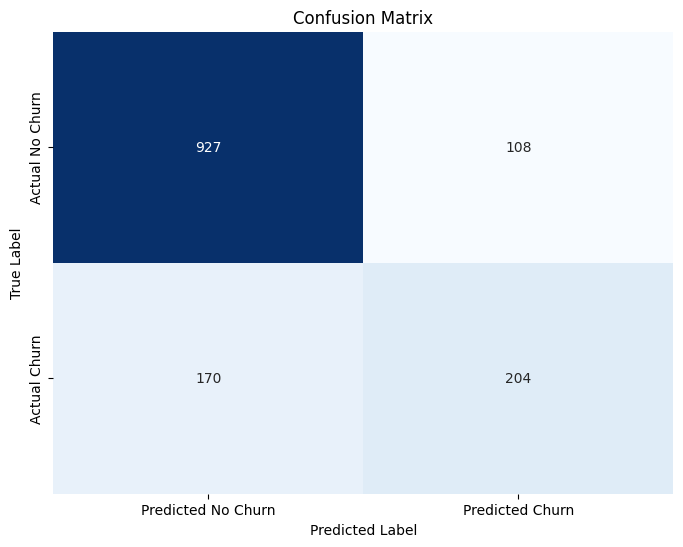

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Churn', 'Predicted Churn'],
            yticklabels=['Actual No Churn', 'Actual Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 8. Feature Importance (Optional but Recommended)

Understanding which features are most important in predicting churn can provide valuable business insights. For Logistic Regression, we can look at the coefficients.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

display(feature_importance)

,Feature,Coefficient
18,InternetService_Fiber optic,0.445811
14,PaperlessBilling,0.393963
1,SeniorCitizen,0.213558
6,MultipleLines,0.208425
12,StreamingMovies,0.130655
11,StreamingTV,0.129946
16,MonthlyCharges,0.012463
2,Partner,0.008340
17,TotalCharges,0.000189
0,gender,-0.010763


### 9. Final Report: Insights and Business Implications

Based on our data analysis and the trained Logistic Regression model, we can draw several insights and discuss their business implications regarding customer churn.

### 10. Making Predictions on New Data

Let's simulate new customer data and use our trained Logistic Regression model to predict whether these new customers are likely to churn. This demonstrates how the model can be used in a real-world scenario.

In [ ]:
import pandas as pd

# Create sample new customer data (ensure it has the same columns as X_train)
# For demonstration, let's create a DataFrame with a few hypothetical new customers.
# The values should be in the same format as the processed X_train data (numerical/one-hot encoded).
# Let's create two new customers: one likely to churn, one likely not to.

# Example customer 1 (High churn risk - similar to features with positive coefficients)
# Fiber optic, PaperlessBilling, Month-to-month contract, no online security/tech support
new_customer_1 = {
    'gender': 0, # Female
    'SeniorCitizen': 1, # Senior Citizen
    'Partner': 0, # No Partner
    'Dependents': 0, # No Dependents
    'tenure': 5, # Low tenure
    'PhoneService': 1, # Yes Phone Service
    'MultipleLines': 1, # Yes Multiple Lines
    'OnlineSecurity': 0, # No Online Security
    'OnlineBackup': 0, # No Online Backup
    'DeviceProtection': 0, # No Device Protection
    'TechSupport': 0, # No Tech Support
    'StreamingTV': 1, # Yes Streaming TV
    'StreamingMovies': 1, # Yes Streaming Movies
    'Contract': 0, # Month-to-month
    'PaperlessBilling': 1, # Yes Paperless Billing
    'PaymentMethod': 0, # Electronic Check
    'MonthlyCharges': 90.0, # High Monthly Charges
    'TotalCharges': 450.0, # Relatively low total charges due to low tenure
    'InternetService_Fiber optic': True, # Fiber Optic
    'InternetService_No': False # Has Internet Service
}

# Example customer 2 (Low churn risk - similar to features with negative coefficients)
# DSL, longer tenure, Two-year contract, online security/tech support
new_customer_2 = {
    'gender': 1, # Male
    'SeniorCitizen': 0, # Not Senior Citizen
    'Partner': 1, # Has Partner
    'Dependents': 1, # Has Dependents
    'tenure': 60, # High tenure
    'PhoneService': 1, # Yes Phone Service
    'MultipleLines': 0, # No Multiple Lines
    'OnlineSecurity': 1, # Yes Online Security
    'OnlineBackup': 1, # Yes Online Backup
    'DeviceProtection': 1, # Yes Device Protection
    'TechSupport': 1, # Yes Tech Support
    'StreamingTV': 0, # No Streaming TV
    'StreamingMovies': 0, # No Streaming Movies
    'Contract': 2, # Two year
    'PaperlessBilling': 0, # No Paperless Billing
    'PaymentMethod': 3, # Credit card (automatic)
    'MonthlyCharges': 70.0, # Moderate Monthly Charges
    'TotalCharges': 4200.0, # High Total Charges
    'InternetService_Fiber optic': False, # Not Fiber Optic
    'InternetService_No': False # Has Internet Service
}

# Create a DataFrame from the new customer data
new_customers_df = pd.DataFrame([new_customer_1, new_customer_2])

# Ensure the columns are in the same order as X_train
new_customers_df = new_customers_df[X_train.columns]

print('New Customer Data:')
display(new_customers_df)

# Make predictions on the new data
new_customer_predictions = log_reg_model.predict(new_customers_df)
new_customer_probabilities = log_reg_model.predict_proba(new_customers_df)[:, 1] # Probability of churning

# Add predictions to the new customers DataFrame for easier interpretation
new_customers_df['Predicted_Churn'] = new_customer_predictions
new_customers_df['Churn_Probability'] = new_customer_probabilities

print('\nPredictions for New Customers:')
display(new_customers_df[['Predicted_Churn', 'Churn_Probability']])

# Interpret the results
print('\nInterpretation:')
for i, (pred, prob) in enumerate(zip(new_customer_predictions, new_customer_probabilities)):
    churn_status = 'will churn' if pred == 1 else 'will not churn'
    print(f'Customer {i+1}: Predicted to {churn_status} with a churn probability of {prob:.4f}')

New Customer Data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No
0,0,1,0,0,5,1,1,0,0,0,0,1,1,0,1,0,90.0,450.0,True,False
1,1,0,1,1,60,1,0,1,1,1,1,0,0,2,0,3,70.0,4200.0,False,False



Predictions for New Customers:


,Predicted_Churn,Churn_Probability
0,1,0.830773
1,0,0.004557



Interpretation:
Customer 1: Predicted to will churn with a churn probability of 0.8308
Customer 2: Predicted to will not churn with a churn probability of 0.0046


In [ ]:
# Identify remaining categorical columns (object dtype)
categorical_cols = df.select_dtypes(include='object').columns

if len(categorical_cols) > 0:
    print(f'Applying one-hot encoding to: {list(categorical_cols)}')
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
else:
    print('No more object type columns found for one-hot encoding.')

print('\nDataFrame head after one-hot encoding:')
display(df.head())

print('\nFinal DataFrame Information:')
df.info()

Applying one-hot encoding to: ['InternetService']

DataFrame head after one-hot encoding:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,0,0,0,1,0,29.85,29.85,0,False,False
1,1,0,0,0,34,1,0,1,0,1,...,0,0,1,0,1,56.95,1889.50,0,False,False
2,1,0,0,0,2,1,0,1,1,0,...,0,0,0,1,1,53.85,108.15,1,False,False
3,1,0,0,0,45,0,0,1,0,1,...,0,0,1,0,2,42.30,1840.75,0,False,False
4,0,0,0,0,2,1,0,0,0,0,...,0,0,0,1,0,70.70,151.65,1,True,False



Final DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       7043 non-null   int64  
 1   SeniorCitizen                7043 non-null   int64  
 2   Partner                      7043 non-null   int64  
 3   Dependents                   7043 non-null   int64  
 4   tenure                       7043 non-null   int64  
 5   PhoneService                 7043 non-null   int64  
 6   MultipleLines                7043 non-null   int64  
 7   OnlineSecurity               7043 non-null   int64  
 8   OnlineBackup                 7043 non-null   int64  
 9   DeviceProtection             7043 non-null   int64  
 10  TechSupport                  7043 non-null   int64  
 11  StreamingTV                  7043 non-null   int64  
 12  StreamingMovies              7043 non-null   i